## Cell 1 — Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
OUTPUT_DIR = '/content/drive/MyDrive/insurance_fraud/processed/'
MODEL_DIR  = '/content/drive/MyDrive/insurance_fraud/models/'
PLOT_DIR   = '/content/drive/MyDrive/insurance_fraud/plots/'
REPORT_DIR = '/content/drive/MyDrive/insurance_fraud/reports/'
os.makedirs(REPORT_DIR, exist_ok=True)
print('✅ Drive mounted.')

Mounted at /content/drive
✅ Drive mounted.


## Cell 2 — Install & Import

In [ ]:
!pip install shap reportlab xgboost lightgbm --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import joblib
import json
import warnings
import textwrap
from datetime import datetime
warnings.filterwarnings('ignore')

# PDF generation
from reportlab.lib.pagesizes   import A4
from reportlab.lib             import colors
from reportlab.lib.styles      import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units       import cm
from reportlab.platypus        import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle,
    HRFlowable, Image as RLImage
)
from reportlab.lib.enums       import TA_CENTER, TA_LEFT

# Plot style
NAVY='#0D1B3E'; CARD='#132447'; ACCENT='#1DB8C4'
GREEN='#22C97A'; RED='#E84C4C'; YELLOW='#F5C842'
WHITE='#FFFFFF'; GRAY='#8BA3BF'; PURPLE='#C87EFF'; ORANGE='#FF8C42'
plt.rcParams.update({
    'figure.facecolor': NAVY, 'axes.facecolor': CARD,
    'axes.labelcolor': WHITE, 'xtick.color': WHITE,
    'ytick.color': WHITE, 'text.color': WHITE,
    'axes.titlecolor': WHITE, 'axes.edgecolor': ACCENT,
    'grid.color': '#1D3557', 'grid.alpha': 0.4,
})

def save_plot(fig, name):
    path = PLOT_DIR + name
    fig.savefig(path, dpi=150, bbox_inches='tight', facecolor=NAVY)
    print(f'  💾 {name}')
    return path

print('✅ All libraries imported.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.9 MB/s eta 0:00:00
✅ All libraries imported.


## Cell 3 — Load Models & Data

In [ ]:
# Load trained XGBoost (best single model for SHAP — tree explainer is exact)
xgb_model  = joblib.load(MODEL_DIR + 'model_xgboost.pkl')
lgbm_model = joblib.load(MODEL_DIR + 'model_lightgbm.pkl')

# Load validation set
X_val = pd.read_parquet(MODEL_DIR + 'X_val.parquet')
val_preds = pd.read_parquet(MODEL_DIR + 'val_predictions.parquet')

# Load feature list
with open(OUTPUT_DIR + 'final_feature_columns.json') as f:
    feature_cols = json.load(f)
feature_cols = [c for c in feature_cols if c in X_val.columns]
X_val = X_val[feature_cols]

# Load flag descriptions for natural language explanations
try:
    with open(OUTPUT_DIR + 'flag_descriptions.json') as f:
        flag_desc = json.load(f)
except:
    flag_desc = {}

# Load ensemble metadata
with open(MODEL_DIR + 'model_metadata.json') as f:
    metadata = json.load(f)

y_true        = val_preds['y_true'].values
ensemble_proba = val_preds['ensemble_proba'].values
ensemble_pred  = val_preds['ensemble_pred'].values

print(f'✅ Loaded:')
print(f'   XGBoost model')
print(f'   X_val shape     : {X_val.shape}')
print(f'   Validation preds: {len(val_preds):,} providers')
print(f'   Feature count   : {len(feature_cols)}')
print(f'   Best model AUC  : {metadata["val_auc_roc"]}')
print(f'   Best threshold  : {metadata["best_threshold"]}')

✅ Loaded:
   XGBoost model
   X_val shape     : (1082, 74)
   Validation preds: 1,082 providers
   Feature count   : 74
   Best model AUC  : 0.9704
   Best threshold  : 0.73


## Cell 4 — Compute SHAP Values
> TreeExplainer is exact (not approximate) for tree-based models — fast and accurate

In [ ]:
print('📊 Computing SHAP values with TreeExplainer...')
print('   (This is exact, not approximate — takes ~30-60 seconds)')

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_val)

# shap_values.values shape: (n_samples, n_features)
# Positive SHAP = pushes prediction toward FRAUD
# Negative SHAP = pushes prediction toward LEGIT

shap_df = pd.DataFrame(
    shap_values.values,
    columns=feature_cols
)

print(f'\n✅ SHAP values computed.')
print(f'   Shape: {shap_df.shape}')
print(f'   Mean |SHAP| per feature (top 10):')
mean_abs = shap_df.abs().mean().sort_values(ascending=False)
for feat, val in mean_abs.head(10).items():
    print(f'     {feat:<45} {val:.4f}')

📊 Computing SHAP values with TreeExplainer...
   (This is exact, not approximate — takes ~30-60 seconds)

✅ SHAP values computed.
   Shape: (1082, 74)
   Mean |SHAP| per feature (top 10):
     ip_max_stay_days                              2.0002
     feat_claims_per_patient                       0.6773
     op_total_deductible                           0.6090
     op_total_reimbursement                        0.5832
     op_unique_attending_phys                      0.5026
     bin_total_unique_patients                     0.4953
     feat_max_abs_zscore                           0.4626
     op_claim_count                                0.4522
     op_max_reimbursement                          0.3746
     avg_reimb_per_patient                         0.3587


## Cell 5 — Plot 1: SHAP Summary Plot (Global Feature Importance)

  💾 plot_M5_shap_summary.png


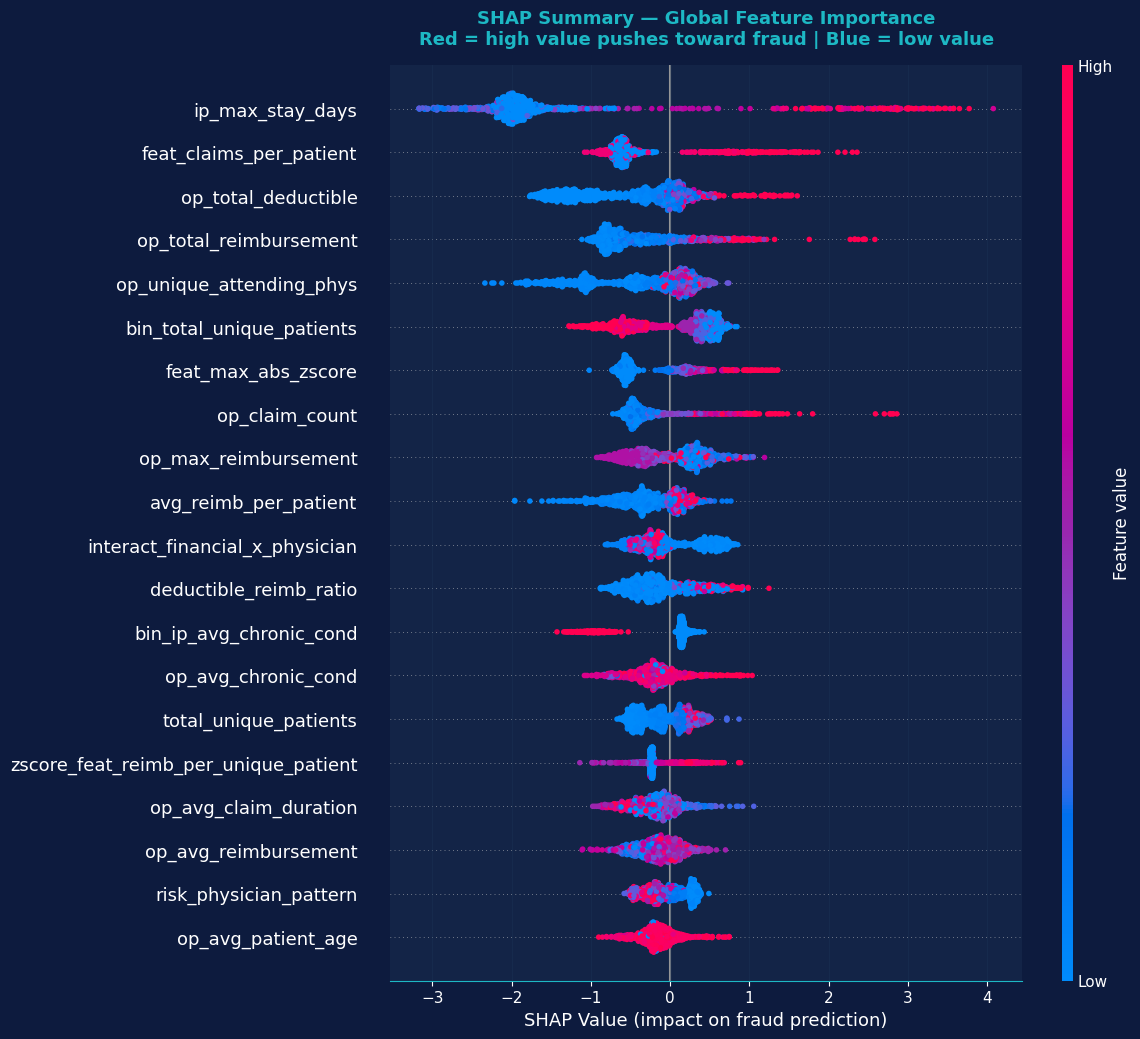

In [ ]:
# Summary plot shows: which features matter most AND in which direction
# Red dots = high feature value, Blue = low value
# Right side = pushes toward FRAUD, Left = toward LEGIT

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor(NAVY)

shap.summary_plot(
    shap_values.values,
    X_val,
    feature_names=feature_cols,
    max_display=20,
    show=False,
    plot_size=None,
    color_bar=True,
)

ax = plt.gca()
ax.set_facecolor(CARD)
ax.tick_params(colors=WHITE)
ax.set_xlabel('SHAP Value (impact on fraud prediction)', color=WHITE)
ax.xaxis.grid(True, color='#1D3557', alpha=0.4)

plt.title('SHAP Summary — Global Feature Importance\n'
          'Red = high value pushes toward fraud | Blue = low value',
          color=ACCENT, fontsize=13, fontweight='bold', pad=15)

summary_path = save_plot(fig, 'plot_M5_shap_summary.png')
plt.show()

## Cell 6 — Plot 2: SHAP Bar Plot (Mean Absolute Importance)

  💾 plot_M5_shap_bar.png


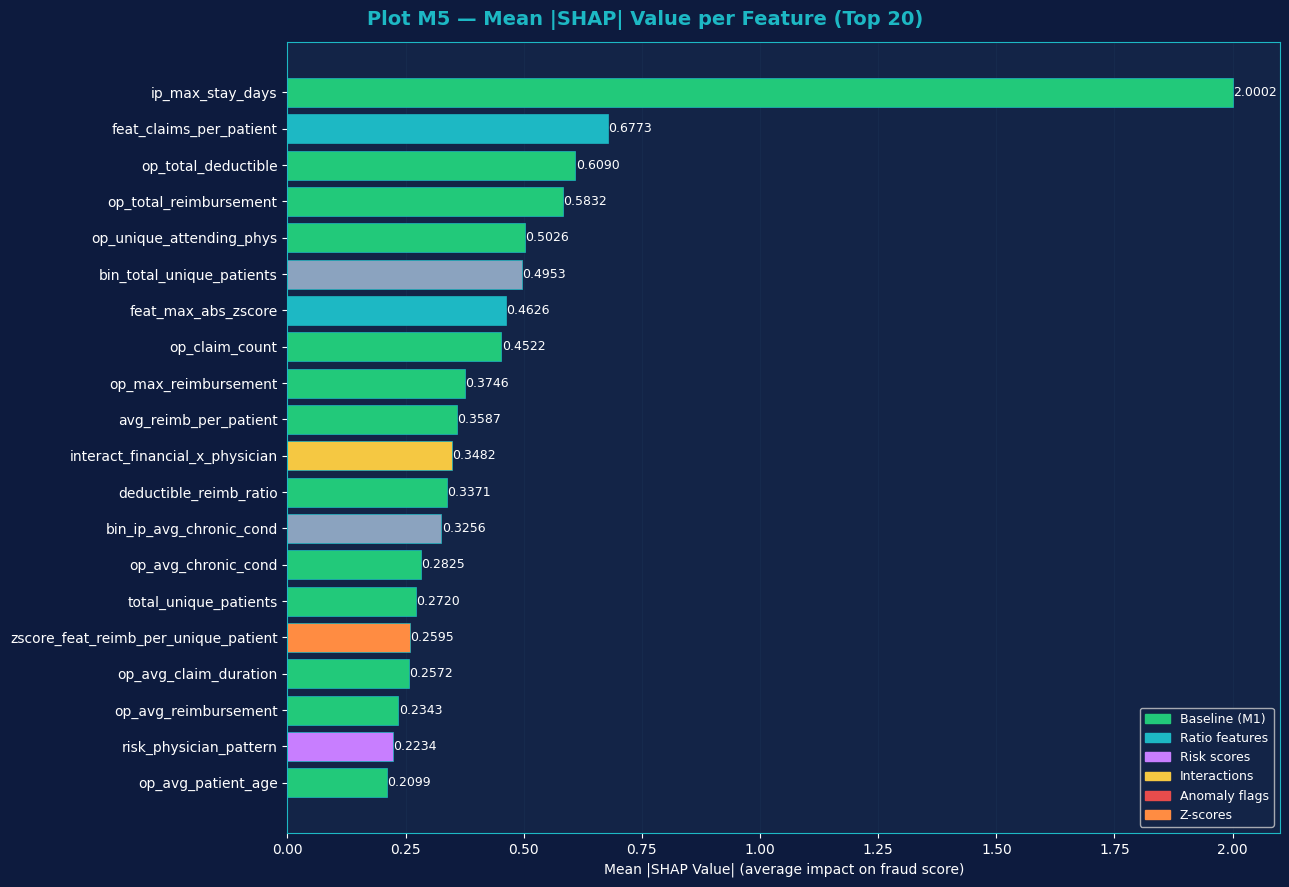

In [ ]:
# Mean absolute SHAP value = average impact on model output magnitude
mean_abs_shap = pd.DataFrame({
    'feature'    : feature_cols,
    'mean_abs_shap': np.abs(shap_values.values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).head(20)

def get_color(f):
    if f.startswith('risk_'):      return PURPLE
    if f.startswith('interact_'):  return YELLOW
    if f.startswith('feat_'):      return ACCENT
    if f.startswith('flag_'):      return RED
    if f.startswith('zscore_'):    return ORANGE
    if f.startswith('bin_'):       return GRAY
    return GREEN

colors_bar = [get_color(f) for f in mean_abs_shap['feature']]

fig, ax = plt.subplots(figsize=(13, 9))
fig.suptitle('Plot M5 — Mean |SHAP| Value per Feature (Top 20)',
             fontsize=14, fontweight='bold', color=ACCENT)

bars = ax.barh(
    mean_abs_shap['feature'][::-1],
    mean_abs_shap['mean_abs_shap'][::-1],
    color=colors_bar[::-1],
    edgecolor=ACCENT, linewidth=0.5
)
for bar, val in zip(bars, mean_abs_shap['mean_abs_shap'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, color=WHITE)

ax.set_xlabel('Mean |SHAP Value| (average impact on fraud score)')
ax.xaxis.grid(True); ax.set_axisbelow(True)

legend_items = [
    mpatches.Patch(color=GREEN,  label='Baseline (M1)'),
    mpatches.Patch(color=ACCENT, label='Ratio features'),
    mpatches.Patch(color=PURPLE, label='Risk scores'),
    mpatches.Patch(color=YELLOW, label='Interactions'),
    mpatches.Patch(color=RED,    label='Anomaly flags'),
    mpatches.Patch(color=ORANGE, label='Z-scores'),
]
ax.legend(handles=legend_items, fontsize=9, loc='lower right')
plt.tight_layout()
save_plot(fig, 'plot_M5_shap_bar.png')
plt.show()

## Cell 7 — Plot 3: SHAP Waterfall — Single Provider Explanation

📋 Explaining Provider at index 662:
   Ensemble fraud score : 0.9983
   True label           : FRAUD
   Predicted            : FRAUD
  💾 plot_M5_waterfall_provider_662.png


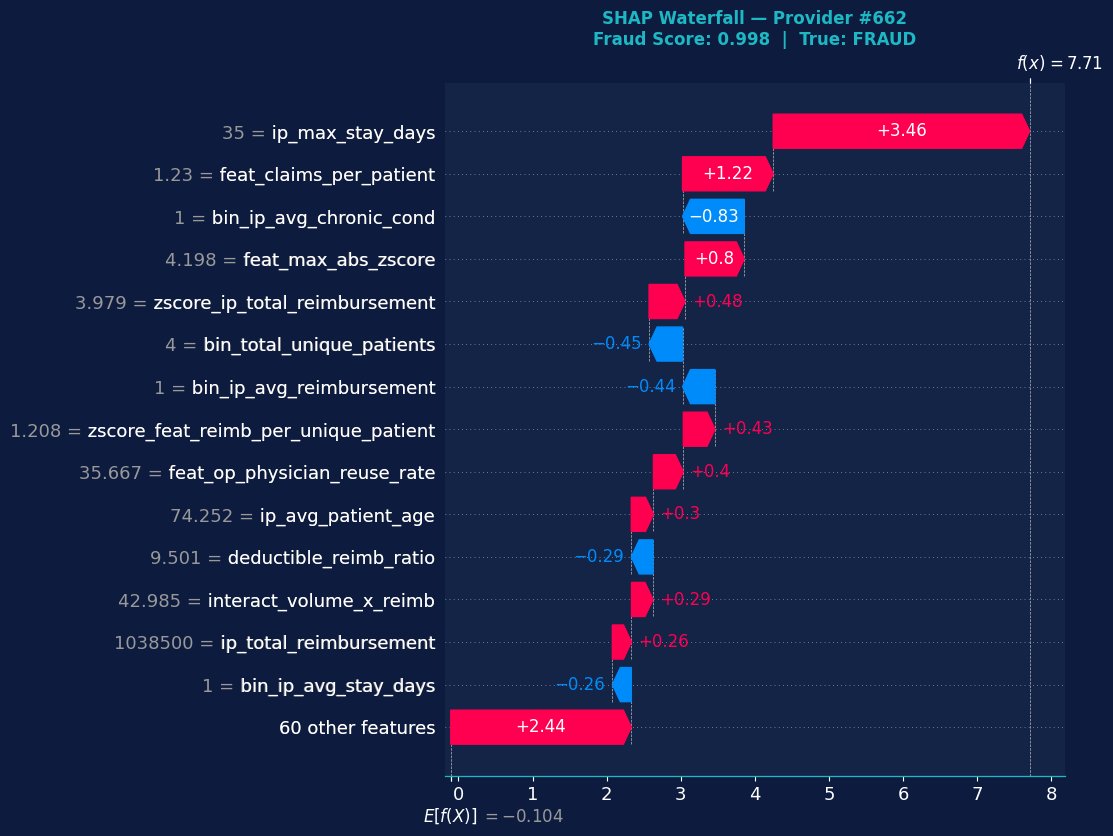

In [ ]:
# Waterfall plot: shows exactly HOW a single prediction was made
# Starting from base rate → each feature adds or subtracts → final score

threshold = metadata['best_threshold']

# Pick the highest-confidence fraud provider in the val set
fraud_indices = np.where((ensemble_pred == 1) & (y_true == 1))[0]
if len(fraud_indices) == 0:
    fraud_indices = np.where(ensemble_proba > threshold)[0]

# Sort by confidence — take the top one
top_fraud_idx = fraud_indices[np.argmax(ensemble_proba[fraud_indices])]

print(f'📋 Explaining Provider at index {top_fraud_idx}:')
print(f'   Ensemble fraud score : {ensemble_proba[top_fraud_idx]:.4f}')
print(f'   True label           : {"FRAUD" if y_true[top_fraud_idx]==1 else "LEGIT"}')
print(f'   Predicted            : {"FRAUD" if ensemble_pred[top_fraud_idx]==1 else "LEGIT"}')

fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor(NAVY)

shap.waterfall_plot(
    shap_values[top_fraud_idx],
    max_display=15,
    show=False
)
ax = plt.gca()
ax.set_facecolor(CARD)
ax.tick_params(colors=WHITE)

plt.title(
    f'SHAP Waterfall — Provider #{top_fraud_idx}\n'
    f'Fraud Score: {ensemble_proba[top_fraud_idx]:.3f}  |  '
    f'True: {"FRAUD" if y_true[top_fraud_idx]==1 else "LEGIT"}',
    color=ACCENT, fontsize=12, fontweight='bold'
)

waterfall_path = save_plot(fig, f'plot_M5_waterfall_provider_{top_fraud_idx}.png')
plt.show()

## Cell 8 — Plot 4: SHAP Dependence Plots (Top 3 Features)

  💾 plot_M5_shap_dependence.png


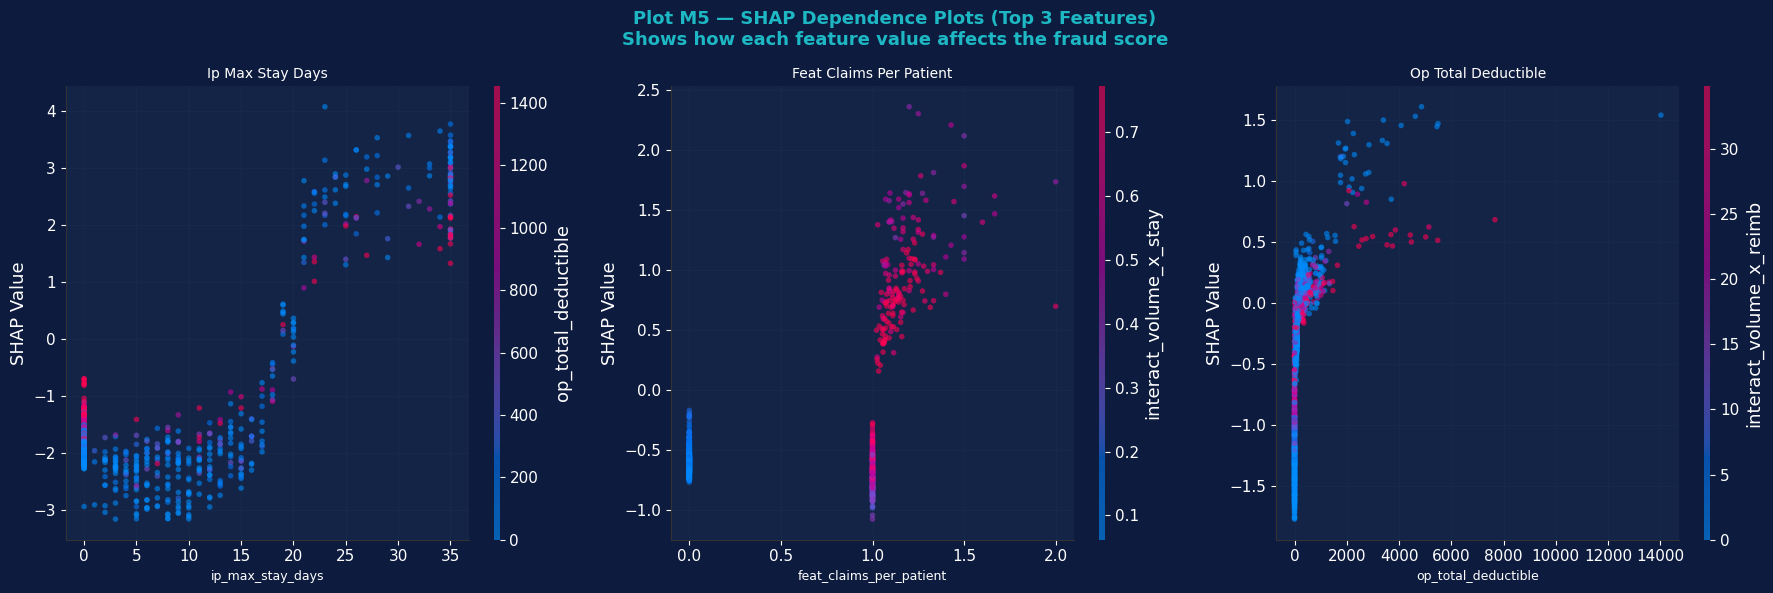

In [ ]:
# Dependence plot: shows how a feature value relates to its SHAP impact
# Color = interaction feature (auto-detected by SHAP)

top3_features = mean_abs_shap['feature'].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Plot M5 — SHAP Dependence Plots (Top 3 Features)\n'
             'Shows how each feature value affects the fraud score',
             fontsize=13, fontweight='bold', color=ACCENT)

for ax, feat in zip(axes, top3_features):
    shap.dependence_plot(
        feat,
        shap_values.values,
        X_val,
        ax=ax,
        show=False,
        alpha=0.6
    )
    ax.set_facecolor(CARD)
    ax.tick_params(colors=WHITE)
    ax.set_xlabel(feat, color=WHITE, fontsize=9)
    ax.set_ylabel('SHAP Value', color=WHITE)
    short = feat.replace('_',' ').replace('ip ','IP ').replace('op ','OP ').title()
    ax.set_title(short, color=WHITE, fontsize=10)
    ax.xaxis.grid(True, alpha=0.3); ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

plt.tight_layout()
save_plot(fig, 'plot_M5_shap_dependence.png')
plt.show()

## Cell 9 — Natural Language Fraud Reason Generator
> This is what your XAI layer outputs to investigators — plain English, not numbers

In [ ]:
# Pre-compute population averages for comparison statements
pop_means = X_val.mean().to_dict()

# Human-readable templates for each feature
FEATURE_TEMPLATES = {
    'ip_avg_reimbursement'       : 'Average inpatient reimbursement of ${val:,.0f} is {ratio:.1f}x the population average (${avg:,.0f})',
    'ip_total_reimbursement'     : 'Total inpatient billing of ${val:,.0f} is {ratio:.1f}x the typical provider (${avg:,.0f})',
    'ip_claim_count'             : 'Filed {val:.0f} inpatient claims — {ratio:.1f}x the average provider ({avg:.0f} claims)',
    'total_unique_patients'      : 'Served {val:.0f} unique patients — {ratio:.1f}x the typical provider ({avg:.0f} patients)',
    'ip_avg_stay_days'           : 'Average hospital stay of {val:.1f} days is {ratio:.1f}x longer than average ({avg:.1f} days)',
    'ip_avg_chronic_cond'        : 'Patients average {val:.2f} chronic conditions — {ratio:.1f}x higher than population ({avg:.2f})',
    'ip_unique_attending_phys'   : 'Used {val:.0f} unique physicians — {ratio:.1f}x more than typical provider ({avg:.0f})',
    'feat_reimb_per_unique_patient': 'Extracts ${val:,.0f} per unique patient — {ratio:.1f}x population average (${avg:,.0f})',
    'feat_claims_per_patient'    : 'Files {val:.2f} claims per patient — {ratio:.1f}x average ({avg:.2f}) — possible duplicate billing',
    'feat_op_physician_reuse_rate': 'Same operating physician used across {val:.1f} claims — high reuse rate signals fake procedures',
    'risk_composite_score'       : 'Composite fraud risk score of {val:.3f} (range 0–1) — top {pct:.0f}% most suspicious providers',
    'risk_financial'             : 'Financial risk score {val:.3f} — in the top {pct:.0f}% for billing abnormality',
    'feat_total_flags_triggered' : 'Triggered {val:.0f} out of 8 anomaly flags — each flag = extreme outlier on a key metric',
    'interact_volume_x_reimb'    : 'High claim volume combined with high reimbursement — classic billing mill pattern',
    'interact_patients_x_chronic': 'Large patient base with inflated chronic condition scores — diagnosis stuffing signal',
    'ip_deceased_patient_count'  : 'Filed {val:.0f} claims for deceased patients — possible post-death billing fraud',
    'feat_deductible_ratio'      : 'Deductible-to-reimbursement ratio of {val:.3f} — abnormally low deductible for claim size',
    'zscore_ip_avg_reimbursement': 'Reimbursement {val:+.1f} standard deviations above mean — statistically extreme outlier',
}


def generate_fraud_reasons(provider_idx, shap_vals, X_val, top_n=5):
    """
    Generates top N natural language fraud reasons for a provider.
    Uses SHAP values to rank which features contributed most to the fraud score.
    """
    provider_shap = shap_vals.values[provider_idx]   # SHAP values for this provider
    provider_feat = X_val.iloc[provider_idx]          # Actual feature values

    # Only positive SHAP = features pushing toward fraud
    fraud_shap = [(feat, provider_shap[i], provider_feat[feat])
                  for i, feat in enumerate(feature_cols)
                  if provider_shap[i] > 0]

    # Sort by SHAP magnitude — highest impact first
    fraud_shap.sort(key=lambda x: x[1], reverse=True)

    reasons = []
    for feat, shap_val, feat_val in fraud_shap[:top_n]:
        template = FEATURE_TEMPLATES.get(feat)
        avg = pop_means.get(feat, 0)
        ratio = feat_val / max(avg, 1e-9)
        pct   = (pd.Series(X_val[feat]) <= feat_val).mean() * 100

        if template:
            try:
                reason_text = template.format(
                    val=feat_val, avg=avg,
                    ratio=ratio, pct=pct
                )
            except:
                reason_text = f'{feat}: {feat_val:.3f} (SHAP impact: +{shap_val:.4f})'
        else:
            reason_text = (f'{feat.replace("_"," ").title()}: value={feat_val:.3f}, '
                           f'{ratio:.1f}x average, SHAP impact: +{shap_val:.4f}')

        reasons.append({
            'feature'    : feat,
            'shap_value' : round(shap_val, 4),
            'feat_value' : round(feat_val, 4),
            'reason_text': reason_text
        })

    return reasons


# Demo: generate reasons for top 3 flagged providers
print('🔍 NATURAL LANGUAGE FRAUD EXPLANATIONS')
print('='*65)

flagged_indices = np.argsort(ensemble_proba)[::-1][:5]  # Top 5 most suspicious

for rank, idx in enumerate(flagged_indices, 1):
    score = ensemble_proba[idx]
    true  = 'FRAUD' if y_true[idx] == 1 else 'LEGIT'
    reasons = generate_fraud_reasons(idx, shap_values, X_val, top_n=5)

    print(f'\n  Provider Rank #{rank}  |  Fraud Score: {score:.4f}  |  True Label: {true}')
    print(f'  Top Fraud Signals:')
    for i, r in enumerate(reasons, 1):
        print(f'    {i}. {r["reason_text"]}')
        print(f'       (SHAP contribution: +{r["shap_value"]:.4f})')
    print(f'  {"─"*60}')

print('\n✅ Natural language reasons generated.')

🔍 NATURAL LANGUAGE FRAUD EXPLANATIONS

  Provider Rank #1  |  Fraud Score: 0.9983  |  True Label: FRAUD
  Top Fraud Signals:
    1. Ip Max Stay Days: value=35.000, 5.7x average, SHAP impact: +3.4613
       (SHAP contribution: +3.4613)
    2. Files 1.23 claims per patient — 2.9x average (0.42) — possible duplicate billing
       (SHAP contribution: +1.2240)
    3. Feat Max Abs Zscore: value=4.198, 3.0x average, SHAP impact: +0.8001
       (SHAP contribution: +0.8001)
    4. Zscore Ip Total Reimbursement: value=3.979, 124.5x average, SHAP impact: +0.4848
       (SHAP contribution: +0.4848)
    5. Zscore Feat Reimb Per Unique Patient: value=1.208, 56.5x average, SHAP impact: +0.4281
       (SHAP contribution: +0.4281)
  ────────────────────────────────────────────────────────────

  Provider Rank #2  |  Fraud Score: 0.9981  |  True Label: FRAUD
  Top Fraud Signals:
    1. Ip Max Stay Days: value=35.000, 5.7x average, SHAP impact: +3.7733
       (SHAP contribution: +3.7733)
    2. Files 1.

## Cell 10 — Risk Tier Classification

📊 Risk Tier Distribution:
  CRITICAL  :   67 providers (  6.2%)
  HIGH      :   15 providers (  1.4%)
  MEDIUM    :   26 providers (  2.4%)
  LOW       :  974 providers ( 90.0%)

  💾 provider_risk_table.parquet saved
  💾 plot_M5_risk_tiers.png


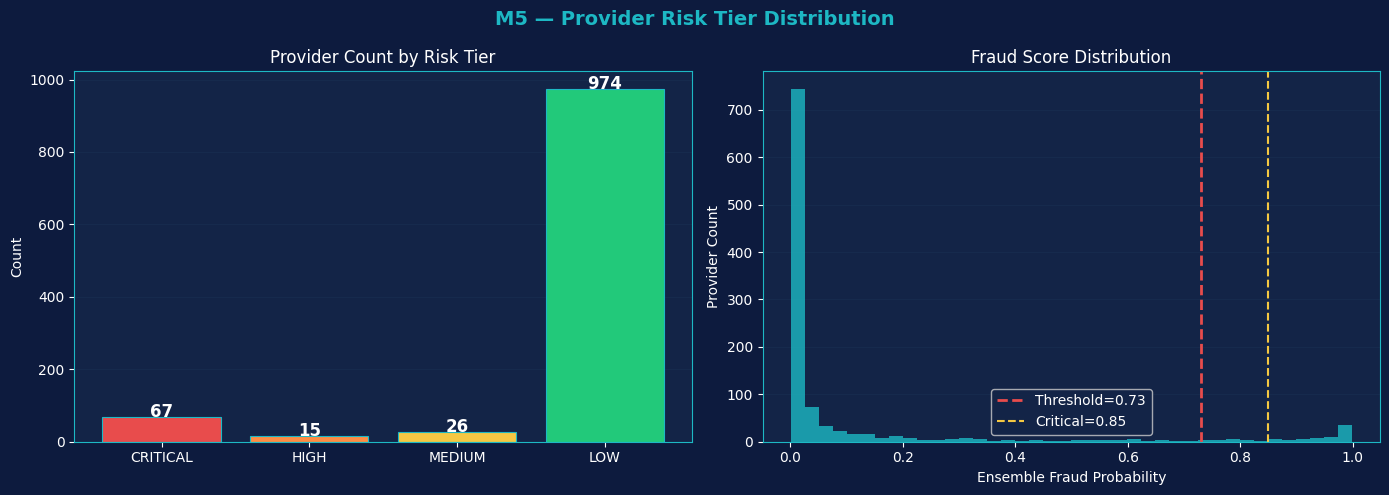

In [ ]:
def get_risk_tier(score, threshold):
    """Classify provider into actionable risk tier."""
    if score >= 0.85:
        return 'CRITICAL', RED,    'Immediate investigation required'
    elif score >= threshold:
        return 'HIGH',     ORANGE, 'Flag for detailed manual review'
    elif score >= threshold * 0.7:
        return 'MEDIUM',   YELLOW, 'Monitor and schedule periodic review'
    else:
        return 'LOW',      GREEN,  'Within normal parameters'

threshold = metadata['best_threshold']

# Build full risk table for all val providers
risk_rows = []
for i in range(len(X_val)):
    tier, color, action = get_risk_tier(ensemble_proba[i], threshold)
    reasons = generate_fraud_reasons(i, shap_values, X_val, top_n=3)
    top_reason = reasons[0]['reason_text'] if reasons else 'No specific signal'
    risk_rows.append({
        'provider_idx'  : i,
        'fraud_score'   : round(ensemble_proba[i], 4),
        'predicted'     : int(ensemble_pred[i]),
        'true_label'    : int(y_true[i]),
        'risk_tier'     : tier,
        'action'        : action,
        'top_reason'    : top_reason,
    })

risk_df = pd.DataFrame(risk_rows).sort_values('fraud_score', ascending=False)

print('📊 Risk Tier Distribution:')
tier_counts = risk_df['risk_tier'].value_counts()
for tier, count in [('CRITICAL', 0), ('HIGH', 0), ('MEDIUM', 0), ('LOW', 0)]:
    c = tier_counts.get(tier, 0)
    pct = c / len(risk_df) * 100
    print(f'  {tier:<10}: {c:>4} providers ({pct:5.1f}%)')

# Save for report generation
risk_df.to_parquet(REPORT_DIR + 'provider_risk_table.parquet', index=False)
print(f'\n  💾 provider_risk_table.parquet saved')

# Plot tier distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('M5 — Provider Risk Tier Distribution', fontsize=14, fontweight='bold', color=ACCENT)

tier_order  = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']
tier_colors = [RED, ORANGE, YELLOW, GREEN]
tier_vals   = [tier_counts.get(t, 0) for t in tier_order]

ax = axes[0]
bars = ax.bar(tier_order, tier_vals, color=tier_colors, edgecolor=ACCENT, linewidth=0.8)
for bar, val in zip(bars, tier_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', fontsize=12, color=WHITE, fontweight='bold')
ax.set_title('Provider Count by Risk Tier')
ax.set_ylabel('Count')
ax.yaxis.grid(True); ax.set_axisbelow(True)

ax = axes[1]
ax.hist(ensemble_proba, bins=40, color=ACCENT, edgecolor='none', alpha=0.8)
ax.axvline(threshold, color=RED, linestyle='--', linewidth=2, label=f'Threshold={threshold}')
ax.axvline(0.85, color=YELLOW, linestyle='--', linewidth=1.5, label='Critical=0.85')
ax.set_title('Fraud Score Distribution')
ax.set_xlabel('Ensemble Fraud Probability')
ax.set_ylabel('Provider Count')
ax.legend()
ax.yaxis.grid(True); ax.set_axisbelow(True)

plt.tight_layout()
save_plot(fig, 'plot_M5_risk_tiers.png')
plt.show()

## Cell 11 — Auto-Generate Investigator PDF Report
> Generates a professional PDF for the top flagged providers — ready to hand to an investigator

In [ ]:
def generate_investigator_pdf(provider_indices, output_path, waterfall_paths=None):
    """
    Generates a professional PDF fraud investigation report.
    Each provider gets a full page with:
    - Fraud score + risk tier
    - Top 5 fraud reasons in plain English
    - Feature values table
    - SHAP waterfall chart (if available)
    """
    doc    = SimpleDocTemplate(output_path, pagesize=A4,
                               leftMargin=2*cm, rightMargin=2*cm,
                               topMargin=2*cm, bottomMargin=2*cm)
    styles = getSampleStyleSheet()
    story  = []

    # Custom styles
    title_style = ParagraphStyle('Title', parent=styles['Title'],
        fontSize=20, textColor=colors.HexColor('#1DB8C4'),
        spaceAfter=6, alignment=TA_CENTER)
    subtitle_style = ParagraphStyle('Subtitle', parent=styles['Normal'],
        fontSize=11, textColor=colors.HexColor('#8BA3BF'),
        spaceAfter=12, alignment=TA_CENTER)
    section_style = ParagraphStyle('Section', parent=styles['Heading2'],
        fontSize=13, textColor=colors.HexColor('#1DB8C4'), spaceAfter=6)
    body_style = ParagraphStyle('Body', parent=styles['Normal'],
        fontSize=10, textColor=colors.HexColor('#333333'), spaceAfter=4)
    reason_style = ParagraphStyle('Reason', parent=styles['Normal'],
        fontSize=10, textColor=colors.HexColor('#222222'),
        spaceAfter=3, leftIndent=12)

    # ── Cover page ─────────────────────────────────────────────────────────────
    story.append(Spacer(1, 1.5*cm))
    story.append(Paragraph('INSURANCE FRAUD INVESTIGATION REPORT', title_style))
    story.append(Paragraph(
        f'Generated: {datetime.now().strftime("%B %d, %Y at %H:%M")} | '
        f'System: Multimodal Fraud Detection v1.0 | '
        f'Model AUC: {metadata["val_auc_roc"]}',
        subtitle_style
    ))
    story.append(HRFlowable(width='100%', thickness=1.5,
                             color=colors.HexColor('#1DB8C4')))
    story.append(Spacer(1, 0.5*cm))

    # Summary table
    critical = sum(1 for i in provider_indices
                   if ensemble_proba[i] >= 0.85)
    high     = sum(1 for i in provider_indices
                   if threshold <= ensemble_proba[i] < 0.85)

    summary_data = [
        ['Metric', 'Value'],
        ['Providers Analysed',       str(len(provider_indices))],
        ['Critical Risk (≥0.85)',    str(critical)],
        ['High Risk (≥threshold)',   str(high)],
        ['Detection Threshold',      str(threshold)],
        ['Model F1-Score',           str(metadata['val_f1'])],
        ['Model Precision',          str(metadata['val_precision'])],
    ]
    summary_table = Table(summary_data, colWidths=[9*cm, 7*cm])
    summary_table.setStyle(TableStyle([
        ('BACKGROUND',  (0,0), (-1,0), colors.HexColor('#1A3A6B')),
        ('TEXTCOLOR',   (0,0), (-1,0), colors.white),
        ('FONTNAME',    (0,0), (-1,0), 'Helvetica-Bold'),
        ('FONTSIZE',    (0,0), (-1,-1), 10),
        ('ROWBACKGROUNDS', (0,1), (-1,-1),
         [colors.HexColor('#F5F8FF'), colors.HexColor('#EAEFFA')]),
        ('GRID',        (0,0), (-1,-1), 0.5, colors.HexColor('#CCCCCC')),
        ('PADDING',     (0,0), (-1,-1), 8),
    ]))
    story.append(summary_table)
    story.append(Spacer(1, 1*cm))

    # ── Per-provider pages ─────────────────────────────────────────────────────
    for rank, idx in enumerate(provider_indices, 1):
        score  = ensemble_proba[idx]
        tier, _, action = get_risk_tier(score, threshold)
        true_lbl = 'FRAUD' if y_true[idx] == 1 else 'LEGIT'
        reasons  = generate_fraud_reasons(idx, shap_values, X_val, top_n=5)

        story.append(HRFlowable(width='100%', thickness=1,
                                 color=colors.HexColor('#CCCCCC')))
        story.append(Spacer(1, 0.3*cm))

        # Provider header
        tier_color_map = {
            'CRITICAL': '#E84C4C', 'HIGH': '#FF8C42',
            'MEDIUM':   '#F5C842', 'LOW':  '#22C97A'
        }
        tc = tier_color_map.get(tier, '#333333')
        story.append(Paragraph(
            f'Provider #{rank} — Fraud Score: <font color="{tc}"><b>{score:.4f}</b></font> '
            f'| Risk: <font color="{tc}"><b>{tier}</b></font> '
            f'| True Label: <b>{true_lbl}</b>',
            section_style
        ))
        story.append(Paragraph(f'Recommended Action: {action}', body_style))
        story.append(Spacer(1, 0.2*cm))

        # Fraud reasons
        story.append(Paragraph('<b>Top Fraud Signals:</b>', body_style))
        for i, r in enumerate(reasons, 1):
            story.append(Paragraph(
                f'{i}. {r["reason_text"]} '
                f'<font color="#888888">[SHAP: +{r["shap_value"]:.4f}]</font>',
                reason_style
            ))
        story.append(Spacer(1, 0.3*cm))

        # Top feature values table
        top_feats = [r['feature'] for r in reasons]
        feat_data = [['Feature', 'Provider Value', 'Population Avg', 'Ratio']]
        for feat in top_feats:
            val = X_val.iloc[idx][feat]
            avg = pop_means.get(feat, 0)
            ratio = val / max(avg, 1e-9)
            feat_data.append([
                feat.replace('_',' ').title()[:40],
                f'{val:.3f}',
                f'{avg:.3f}',
                f'{ratio:.2f}x'
            ])
        feat_table = Table(feat_data, colWidths=[8*cm, 3*cm, 3*cm, 2.5*cm])
        feat_table.setStyle(TableStyle([
            ('BACKGROUND',  (0,0), (-1,0), colors.HexColor('#1A3A6B')),
            ('TEXTCOLOR',   (0,0), (-1,0), colors.white),
            ('FONTNAME',    (0,0), (-1,0), 'Helvetica-Bold'),
            ('FONTSIZE',    (0,0), (-1,-1), 9),
            ('ROWBACKGROUNDS', (0,1), (-1,-1),
             [colors.HexColor('#F5F8FF'), colors.HexColor('#EAEFFA')]),
            ('GRID',        (0,0), (-1,-1), 0.5, colors.HexColor('#CCCCCC')),
            ('PADDING',     (0,0), (-1,-1), 6),
        ]))
        story.append(feat_table)
        story.append(Spacer(1, 0.5*cm))

    doc.build(story)
    print(f'  ✅ PDF saved: {output_path}')
    return output_path


# Generate report for top 10 flagged providers
top10_indices = np.argsort(ensemble_proba)[::-1][:10].tolist()
report_path   = REPORT_DIR + f'fraud_investigation_report_{datetime.now().strftime("%Y%m%d_%H%M")}.pdf'

print('📄 Generating investigator PDF report...')
generate_investigator_pdf(top10_indices, report_path)
print(f'\n✅ Report covers top {len(top10_indices)} flagged providers.')

📄 Generating investigator PDF report...
  ✅ PDF saved: /content/drive/MyDrive/insurance_fraud/reports/fraud_investigation_report_20260328_0529.pdf

✅ Report covers top 10 flagged providers.


## Cell 12 — M5 Summary

In [ ]:
print('='*65)
print('  M5 XAI SUMMARY')
print('='*65)
print(f'  SHAP method        : TreeExplainer (exact, not approximate)')
print(f'  Providers explained: {len(X_val):,}')
print(f'  Features explained : {len(feature_cols)}')

print(f'\n  Top 5 fraud-driving features (by mean |SHAP|):')
for i, (feat, val) in enumerate(mean_abs_shap.head(5).iterrows(), 1):
    print(f'    {i}. {mean_abs_shap["feature"].iloc[i-1]:<45} {mean_abs_shap["mean_abs_shap"].iloc[i-1]:.4f}')

print(f'\n  Risk tier breakdown:')
for tier in ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']:
    c = (risk_df['risk_tier'] == tier).sum()
    print(f'    {tier:<10}: {c:>4} providers')

print(f'\n  Plots saved:')
plots = ['plot_M5_shap_summary.png', 'plot_M5_shap_bar.png',
         'plot_M5_shap_dependence.png', 'plot_M5_risk_tiers.png',
         f'plot_M5_waterfall_provider_{top_fraud_idx}.png']
for p in plots:
    print(f'    {PLOT_DIR}{p}')

print(f'\n  PDF report saved to: {report_path}')
print(f'\n📌 Next: M6_Document_Scanner.ipynb')
print('   Upload a real PDF/image claim → OCR → fraud score per field')
print('='*65)

  M5 XAI SUMMARY
  SHAP method        : TreeExplainer (exact, not approximate)
  Providers explained: 1,082
  Features explained : 74

  Top 5 fraud-driving features (by mean |SHAP|):
    1. ip_max_stay_days                              2.0002
    2. feat_claims_per_patient                       0.6773
    3. op_total_deductible                           0.6090
    4. op_total_reimbursement                        0.5832
    5. op_unique_attending_phys                      0.5026

  Risk tier breakdown:
    CRITICAL  :   67 providers
    HIGH      :   15 providers
    MEDIUM    :   26 providers
    LOW       :  974 providers

  Plots saved:
    /content/drive/MyDrive/insurance_fraud/plots/plot_M5_shap_summary.png
    /content/drive/MyDrive/insurance_fraud/plots/plot_M5_shap_bar.png
    /content/drive/MyDrive/insurance_fraud/plots/plot_M5_shap_dependence.png
    /content/drive/MyDrive/insurance_fraud/plots/plot_M5_risk_tiers.png
    /content/drive/MyDrive/insurance_fraud/plots/plot_M5_wa